# Study of the network of Twitch gamers

OULD AKLOUCHE Sarah, PINATEL Olivier

## Imports

In [1]:
%pip install networkx
%pip install networkx python-louvain pandas
%pip install igraph leidenalg pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkx as nx
import pandas as pd
import community as community_louvain
import igraph as ig
import leidenalg as la
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

## Reading the data

In [3]:
# Lire les données
df=pd.read_csv("data/large_twitch_features.csv")
df2=pd.read_csv("data/large_twitch_edges.csv")

## Descriptive statistics

In [7]:
df.head()

,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0


In [13]:
len(df)

168114

In [16]:
mapping_m = {0: "Not mature", 1: "Mature"}
df["mature_cl"] = df["mature"].map(mapping_m)
mapping_a = {0: "Not affiliate", 1: "Affiliate"}
df["affiliate_cl"] = df["affiliate"].map(mapping_a)
df.head()

,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate,mature_cl,affiliate_cl
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1,Mature,Affiliate
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0,Not mature,Not affiliate
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1,Mature,Affiliate
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0,Not mature,Not affiliate
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0,Not mature,Not affiliate


In [20]:
df.groupby("language")["views"].describe()

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
CS,576.0,287614.647569,1.495492e+06,103.0,3967.25,13779.0,46653.75,19445384.0
DA,503.0,106778.586481,4.768160e+05,217.0,3335.00,8599.0,29241.50,5139341.0
DE,9428.0,146274.760819,1.663765e+06,25.0,2167.75,6175.5,19503.25,100394785.0
EN,124411.0,162461.082814,3.367933e+06,0.0,1233.00,3509.0,11471.00,368912220.0
ES,5699.0,125785.250219,1.271431e+06,2.0,1515.50,4440.0,15577.00,63285497.0
FI,652.0,72028.090491,3.019135e+05,128.0,2538.00,7511.0,27296.50,3994591.0
FR,6799.0,175994.915282,2.176433e+06,20.0,2064.50,6027.0,19639.50,108432615.0
HU,427.0,191377.112412,1.098021e+06,64.0,2585.00,7346.0,38530.50,17315463.0
IT,1230.0,163607.550407,1.482317e+06,18.0,1633.50,5023.0,18284.75,38793358.0


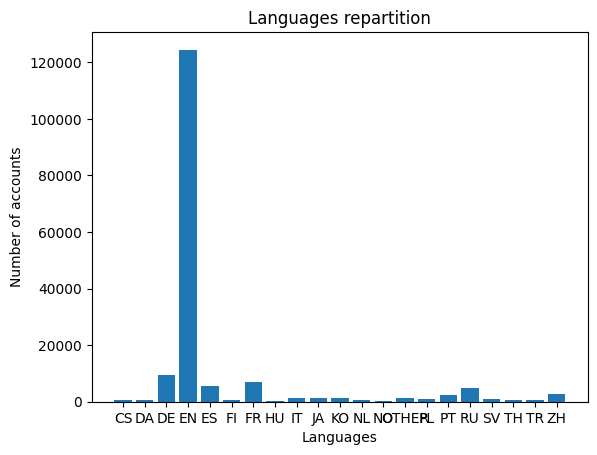

In [9]:
counts = df["language"].value_counts().sort_index()

plt.bar(counts.index, counts.values)

plt.title("Languages repartition")
plt.xlabel("Languages")
plt.ylabel("Number of accounts")

#plt.savefig("Language repartition")
plt.show()

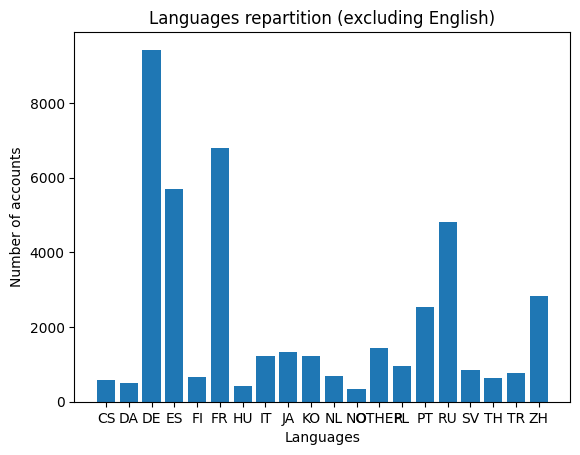

In [10]:
counts_no_english = df[df["language"] != "EN"]["language"].value_counts().sort_index()

plt.bar(counts_no_english.index, counts_no_english.values)

plt.title("Languages repartition (excluding English)")
plt.xlabel("Languages")
plt.ylabel("Number of accounts")

#plt.savefig("Language repartition (excluding English)")
plt.show()

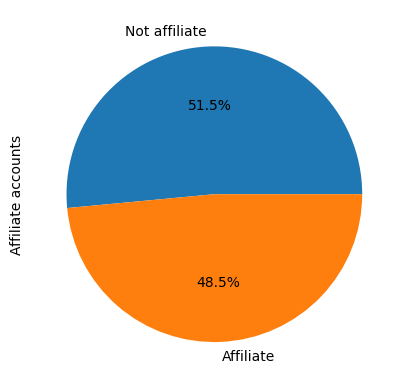

In [17]:
df["affiliate_cl"].value_counts().plot.pie(autopct='%1.1f%%')

plt.ylabel("Affiliate accounts")  
plt.show()

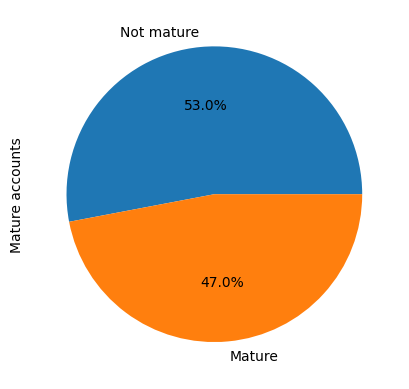

In [18]:
df["mature_cl"].value_counts().plot.pie(autopct='%1.1f%%')

plt.ylabel("Mature accounts")  
plt.show()

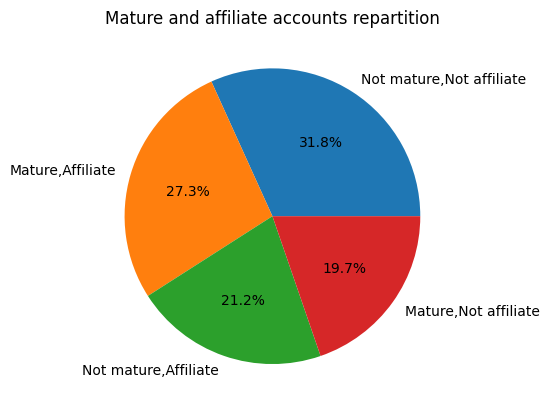

In [19]:
counts_m_a = df.value_counts(subset=['mature_cl', 'affiliate_cl'])

labels = [f"{idx[0]},{idx[1]}" for idx in counts_m_a.index]

plt.pie(counts_m_a, labels=labels, autopct='%1.1f%%')
plt.title("Mature and affiliate accounts repartition")
plt.show()

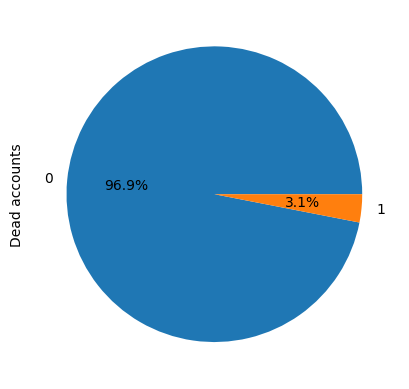

In [21]:
df["dead_account"].value_counts().plot.pie(autopct='%1.1f%%')

plt.ylabel("Dead accounts")  
plt.show()

## Studying the graph

In [4]:
# Création du graphe
G = nx.from_pandas_edgelist(df2, "numeric_id_1", "numeric_id_2", create_using=nx.Graph())

In [ ]:
# Features disponibles
df

,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0
...,...,...,...,...,...,...,...,...,...
168109,4965,0,810,2016-07-20,2018-10-08,168109,0,EN,0
168110,4128,1,2080,2013-01-31,2018-10-12,168110,0,EN,0
168111,3545,0,1797,2013-11-08,2018-10-10,168111,0,EN,1
168112,892736,1,2135,2012-12-07,2018-10-12,168112,0,EN,0


# Label propagation

En premier, nous appliquons l'algorithme de Label propagation pour avoir une première idée de la structure possible du graphe.

In [ ]:
# Tourne en 6 minutes
communities = nx.algorithms.community.label_propagation_communities(G)

partition_lpa = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition_lpa[node] = i

In [6]:
df_nodes_lpa = pd.DataFrame(list(partition_lpa.items()), columns=["node", "community_lpa"])

In [7]:
df_nodes_lpa["community_lpa"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78])

In [8]:
df_nodes_lpa["community_lpa"].value_counts()

community_lpa
0     160091
2       3143
1       2580
6        898
5        633
       ...  
74         2
75         2
76         2
77         2
78         2
Name: count, Length: 79, dtype: int64

79 communautés, avec une communautées très majoritaire.

In [9]:
# On calcule la modularité afin de pouvoir comparer avec la méthode suivante
mod = community_louvain.modularity(partition_lpa, G)
print("Modularité Label Propagation:", mod)

Modularité Label Propagation: 0.03567630678997075


# Louvain

In [10]:
# Met 12 minutes à tourner
partition_louvain = community_louvain.best_partition(
    G,
    resolution=1.0,
    random_state=42
)

In [11]:
df_nodes_louvain = pd.DataFrame(list(partition_louvain.items()), columns=["node", "community"])

In [12]:
df_nodes_louvain["community"].value_counts()

community
3     47419
1     34678
0     24572
2     24146
11     8779
13     6219
5      5080
4      5016
8      4608
29     2010
9      1169
16      826
14      729
15      669
6       539
17      501
10      405
7       367
18      344
22        7
25        5
24        4
19        3
31        3
23        2
21        2
20        2
26        2
27        2
28        2
30        2
12        2
Name: count, dtype: int64

In [13]:
df_nodes_louvain["community"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 29, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 12])

31 communautés, dont 19 avec plus de 10 utilisateurs.

In [14]:
mod = community_louvain.modularity(partition_louvain, G)
print("Modularité:", mod)

Modularité: 0.4179872537787052


Bien meilleure modularité que label propagation, le graphe semble effectivement avoir une structure en communauté exploitable, mais celles ci sont détectables au niveau global et pas vraiment au niveau local.

# Leiden (mais n'utilise pas networkx donc à voir si on garde ou pas)

In [ ]:
g = ig.Graph.TupleList(
    df2.itertuples(index=False), 
    directed=False
)

In [ ]:
# 2 minutes
partition_leiden = la.find_partition(
    g,
    la.RBConfigurationVertexPartition,
    resolution_parameter=1.0
)

In [ ]:
df_nodes_leiden = pd.DataFrame({
    "node": g.vs["name"],
    "community_leiden": partition_leiden.membership
})


In [25]:
df_nodes_leiden["community_leiden"].unique()

array([ 1,  0,  3,  2,  9,  6,  7, 16,  8, 11, 14,  4, 10,  5, 13, 15, 12,
       17, 18, 20, 19, 21, 22, 24, 25, 23])

In [20]:
df_nodes_leiden["community_leiden"].value_counts()

community_leiden
0     47287
1     34229
2     26441
3     18808
4      8864
5      6278
6      5185
7      5162
8      4677
9      3587
10     2010
11     1169
12      856
13      731
14      723
15      678
16      550
17      515
18      346
19        5
20        3
21        2
22        2
24        2
25        2
23        2
Name: count, dtype: int64

24 communautés, 19 avec plus de 300 utilisateurs.

In [21]:
mod = g.modularity(membership)
print("Modularité Leiden:", mod)

Modularité Leiden: 0.42640902097967204


# Comparaison à l'aide de la Mutual Entropy (Normalized Mutual Information) - > pour le moment pose problème

On utilise la NMI pour comparer ces trois algorithmes (a priori LPA est déjà éliminé), on les compare 2 à 2, donc on va obtenir une matrice de similarité. 

In [22]:
def partition_to_labels(partition, nodes):
    label_dict = {}
    for i, community in enumerate(partition):
        for node in community:
            label_dict[node] = i
    return [label_dict[node] for node in nodes]

def dict_to_labels(partition_dict, nodes):
    return [partition_dict[node] for node in nodes]

In [38]:
df = df_nodes_louvain.merge(df_nodes_leiden, on="node")
df = df.merge(df_nodes_lpa, on="node")

In [39]:
nmi_louvain_leiden = normalized_mutual_info_score(df["community"], df["community_leiden"])
nmi_louvain_lpa = normalized_mutual_info_score(df["community"], df["community_lpa"])
nmi_leiden_lpa = normalized_mutual_info_score(df["community_leiden"], df["community_lpa"])

In [40]:
print("Score de NMI entre Louvain et Leiden : " + str(nmi_louvain_leiden))
print("Score de NMI entre Louvain et Label propagation : " + str(nmi_louvain_lpa))
print("Score de NMI entre Leiden et Label propagation : " + str(nmi_leiden_lpa))

Score de NMI entre Louvain et Leiden : 0.7315809038743236
Score de NMI entre Louvain et Label propagation : 0.17672008549483112
Score de NMI entre Leiden et Label propagation : 0.16404408999128328


C'est pas mal.